In [1]:
# Data manipulation library
import numpy as np 
import pandas as pd 
# import data visulization libraries
import matplotlib.pyplot as plt
import seaborn as sns
# import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,RobustScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
# import logging libraries
import logging
logging.basicConfig(level = logging.INFO,
                    filename= 'model.log',
                    filemode= 'w',
                    format= '%(asctime)s - %(message)s - %(levelname)s',
                    force = True)
# Import filter warning libraries
import warnings
warnings.filterwarnings(action= 'ignore')

# steps to be followed

'''
step1:- Data Ingestion : Loading data using pandas function 
step2:- Understand Dataset : Categorical and Numerical column information
step3:- Descriptive Stats for Categorical and Numerical Columns
step4:- Build stratergies based on type and nature of dataset and accordingly do preprocessing
'''

In [2]:
# step1:- data Ingestion

df = pd.read_csv(r'C:\telecom_churnmodel\data\churn.csv')

df.sample(frac = 1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6816,2446-PLQVO,Male,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.30,70.3,Yes
979,6461-PPAXN,Female,0,Yes,Yes,35,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,Yes,Bank transfer (automatic),54.95,1916,No
2234,4500-HKANN,Male,0,Yes,Yes,23,Yes,Yes,DSL,No,...,No,Yes,No,No,Two year,No,Mailed check,59.70,1414.2,No
3301,2636-ALXXZ,Female,1,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.6,Yes
2144,1763-WQFUK,Male,0,No,No,3,Yes,No,DSL,No,...,No,Yes,No,No,Month-to-month,Yes,Mailed check,50.50,147.75,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5467,9770-KXGQU,Female,0,No,No,53,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,One year,No,Mailed check,98.60,5311.85,No
908,4694-PHWFW,Female,0,No,Yes,8,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.95,170.9,No
6845,6127-IYJOZ,Male,1,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,45.85,45.85,No
348,6243-OZGFH,Female,0,No,No,23,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.95,996.85,No


In [3]:
# step2:- Checking dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

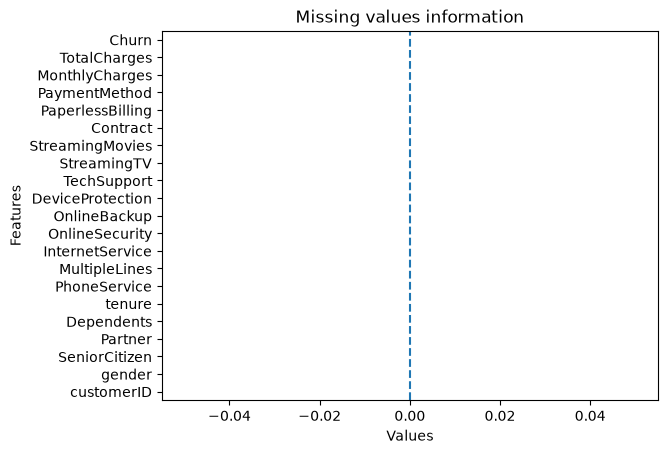

In [4]:
# Checking the missing values 
df.isnull().sum().plot(kind = 'barh')
plt.axvline(0,linestyle = '--')
plt.title('Missing values information')
plt.xlabel('Values')
plt.ylabel('Features')
plt.show()

In [5]:
# checking duplicated values
df.duplicated().sum()

np.int64(0)

In [6]:
numerical_data = df.select_dtypes(exclude = 'object')
categorical_data = df.select_dtypes(include= 'object')

In [7]:
# Encoding target column
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

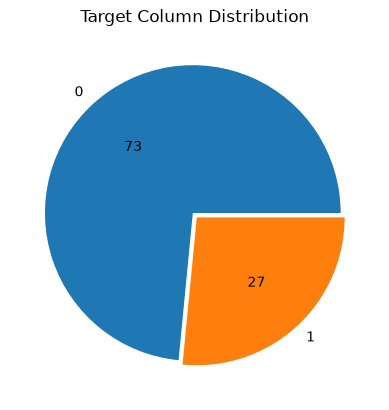

In [8]:
df['Churn'].value_counts().plot(kind = 'pie',
                                autopct = '%0.0f',
                                explode = [0.02,0.02])
plt.title('Target Column Distribution')
plt.show()

In [9]:
# using encoding technique

le = LabelEncoder()
for i in categorical_data.columns:
    df[i] = le.fit_transform(df[i])
    
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4853,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1597,0
7039,1525,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,5698,0
7040,3367,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,2994,0
7041,5934,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,2660,1


In [10]:
# # Dropping Unwanted Columns
df.drop(columns= 'customerID',inplace = True)

In [11]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1


In [12]:
# Data Preprocessing
''' 
1.Nature of Machine Learning Problem : Classification Model.
2.Target Column : Categorical Nature (Yes : 1, No : 0).
3.Before building machine learning model ensure dataset must be balanced.
4.Ensure Data Leakage  must not happen during execution of model :
    -If data leakage found the model becomes overfit.(to prevent it use split method)
5.Matrics for classification models are as follows:
    - confusion matrix(TP,TN,FP,FN)
    - accuracy,precision,recall,f1-score
    - roc and auc curve 
========================================================================================
# Concept of preventing Data Leakage : 
    - split the data into input features and target column i.e. X and y
    - split the dataset into train and test i.e. seen data and unseen data
    - Now use Oversampling or undersampling technique in order to balance target column
    - Building machine learning model 
'''
# Split the dataset into input features and target column i.e. X and y
X = df.drop(columns = 'Churn')
y = df['Churn']

# Split the dataset into train and test : seen and unseen data 

X_Train,X_test,y_train,y_test = train_test_split(X,y,
                                                   test_size = 0.3,
                                                   random_state = 1)

from imblearn.over_sampling import SMOTE
sm = SMOTE()
X_Train,y_train = sm.fit_resample(X_Train,y_train)

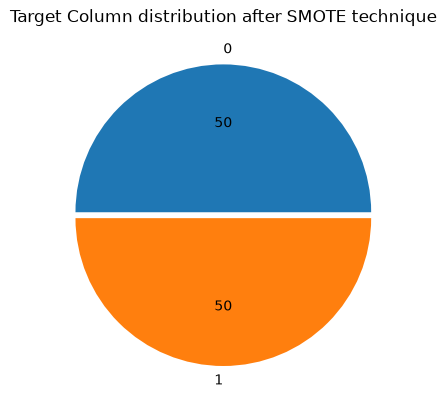

In [13]:
y_train.value_counts().plot(kind = 'pie',
                            autopct = '%0.0f',
                            explode = [0.02,0.02])
plt.title('Target Column distribution after SMOTE technique')
plt.show()

In [14]:
from collections import OrderedDict
stats=[]
for i in df.select_dtypes(exclude='object'):
    numerical_stats=OrderedDict({
        'Feacture':i,
        'count':df[i].count(),
        'mean':df[i].mean(),
        'median':df[i].median(),
        'std':df[i].std(),
        'var':df[i].var(),
        'min':df[i].min(),
        'max':df[i].max(),
        'Q1':df[i].quantile(0.25),
        'Q3':df[i].quantile(0.75),
        'IQR':df[i].quantile(0.75)-df[i].quantile(0.25),
        'LW':df[i].quantile(0.25)-(1.5*(df[i].quantile(0.75)-df[i].quantile(0.25))),
        'UW':df[i].quantile(0.75)+(1.5*(df[i].quantile(0.75)-df[i].quantile(0.25))),
        'Skewness':df[i].skew(),
        'Kurtosis':df[i].kurt(),
        'missingvalue':(df[i].isnull().sum()/len(df))*100
    })
    stats.append(numerical_stats)
    report=pd.DataFrame(stats)
print(report)

            Feacture  count         mean   median          std           var  \
0             gender   7043     0.504756     1.00     0.500013  2.500129e-01   
1      SeniorCitizen   7043     0.162147     0.00     0.368612  1.358745e-01   
2            Partner   7043     0.483033     0.00     0.499748  2.497476e-01   
3         Dependents   7043     0.299588     0.00     0.458110  2.098649e-01   
4             tenure   7043    32.371149    29.00    24.559481  6.031681e+02   
5       PhoneService   7043     0.903166     1.00     0.295752  8.746938e-02   
6      MultipleLines   7043     0.940508     1.00     0.948554  8.997548e-01   
7    InternetService   7043     0.872923     1.00     0.737796  5.443434e-01   
8     OnlineSecurity   7043     0.790004     1.00     0.859848  7.393377e-01   
9       OnlineBackup   7043     0.906432     1.00     0.880162  7.746860e-01   
10  DeviceProtection   7043     0.904444     1.00     0.879949  7.743100e-01   
11       TechSupport   7043     0.797104

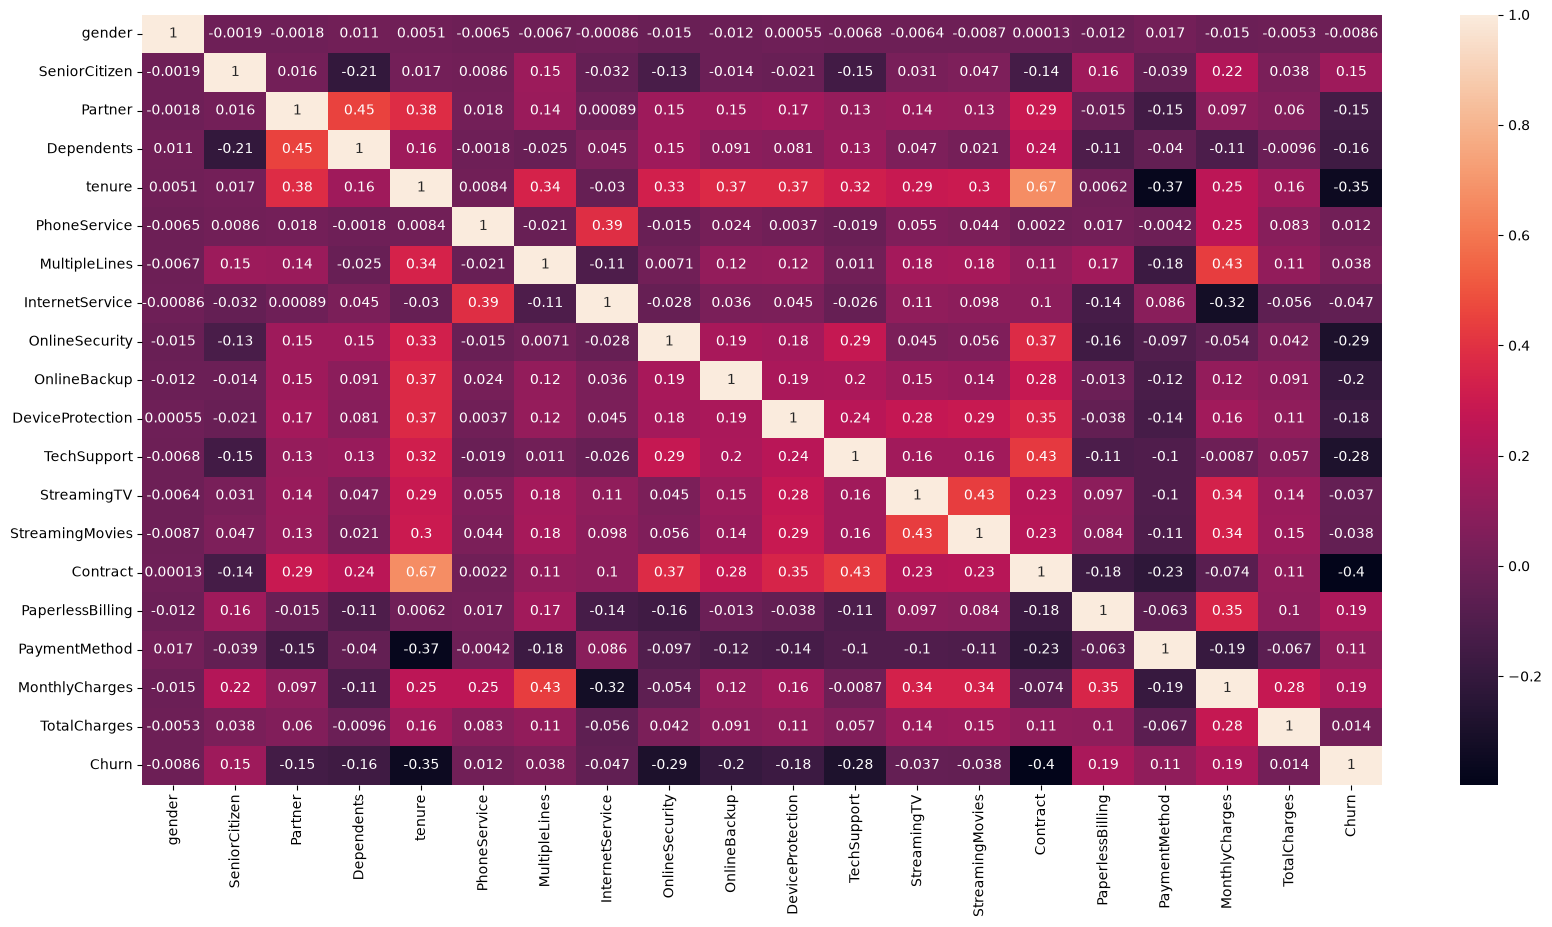

In [15]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

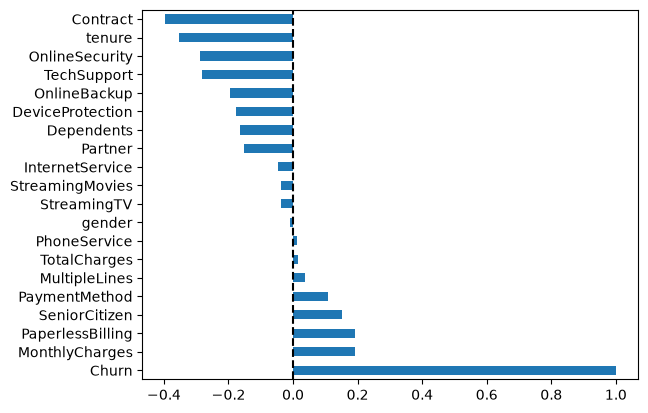

In [16]:
# Checking correlation of between dataset through graph
df.corr()['Churn'].sort_values(ascending=False).plot(kind='barh')
plt.axvline(x=0,linestyle='--',color='k')
plt.show()

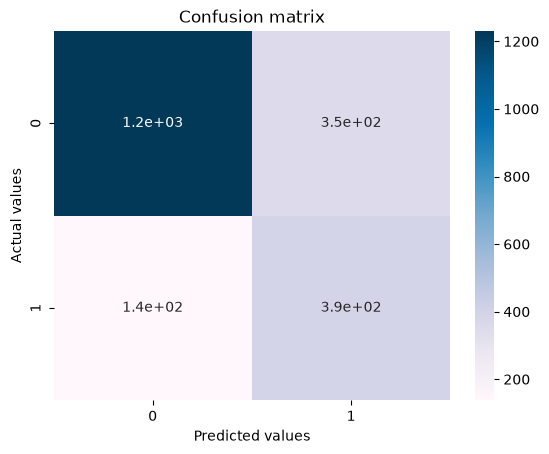

In [29]:
cf = confusion_matrix(y_test,y_pred)
sns.heatmap(cf,annot= True,cmap = 'PuBu')
plt.title('Confusion matrix')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()


In [28]:
# Building Logistic Regression

LR = LogisticRegression().fit(X_Train,y_train)
y_pred = LR.predict(X_test)

classificationreport = classification_report(y_test,y_pred)
print(classificationreport)

              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1585
           1       0.52      0.74      0.61       528

    accuracy                           0.77      2113
   macro avg       0.71      0.76      0.72      2113
weighted avg       0.81      0.77      0.78      2113



In [ ]:
#  applying randomorestclassifier and decisiontreeclassifier

from sklearn.tree import DecisionTreeClassifier

model_DT = DecisionTreeClassifier()
model_DT.fit(X_Train, y_train)

y_pred_dt = model_DT.predict(X_test)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.85      0.80      0.82      1585
           1       0.48      0.56      0.52       528

    accuracy                           0.74      2113
   macro avg       0.66      0.68      0.67      2113
weighted avg       0.75      0.74      0.74      2113



In [27]:
from sklearn.ensemble import RandomForestClassifier

model_RF = RandomForestClassifier()
model_RF.fit(X_Train,y_train)

y_pred_RF = model_RF.predict(X_test)

print(classification_report(y_test, y_pred_RF))

              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1585
           1       0.57      0.63      0.60       528

    accuracy                           0.79      2113
   macro avg       0.72      0.74      0.73      2113
weighted avg       0.80      0.79      0.79      2113

